# Learning by Pruning

Random 2-layer MNIST network with **no weight updates**. Each hidden unit's signed utility is tracked via an exponential trace, and the lowest-utility unit is pruned every `PRUNE_EVERY` steps. The question: can pruning alone produce significantly better than random (10%) accuracy?

In [ ]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from functools import partial

# ── Global hyperparameters (easy to adjust) ──────────────────────────
HIDDEN_SIZE = 1000
PRUNE_EVERY = 200        # steps between pruning events

PRINT_EVERY = 10_000       # steps between status prints
TRACE_DECAY = 1.0 - (1.0 / PRUNE_EVERY)
N_STEPS = HIDDEN_SIZE * PRUNE_EVERY
RESET_TRACES_ON_PRUNE = False
SEED = 42
SCAN_UNROLL = 10

In [57]:
# ── Load MNIST ────────────────────────────────────────────────────────
train_dataset = datasets.MNIST(root="./data", train=True, download=True)

all_images_np = train_dataset.data.numpy().reshape(-1, 784).astype(np.float32)
all_images_np = (all_images_np / 255.0 - 0.1307) / 0.3081
all_labels_np = train_dataset.targets.numpy()

INPUT_SIZE = 784
OUTPUT_SIZE = 10
print(f"Loaded {len(all_labels_np)} training images")

Loaded 60000 training images


In [58]:
# ── Initialize network weights and pruning mask ──────────────────────
key = jax.random.PRNGKey(SEED)
k1, k2 = jax.random.split(key)

W1 = jax.random.normal(k1, (INPUT_SIZE, HIDDEN_SIZE)) * np.sqrt(2.0 / INPUT_SIZE)
b1 = jnp.zeros(HIDDEN_SIZE)
W2 = jax.random.normal(k2, (HIDDEN_SIZE, OUTPUT_SIZE)) * np.sqrt(2.0 / HIDDEN_SIZE)
b2 = jnp.zeros(OUTPUT_SIZE)

mask = jnp.ones(HIDDEN_SIZE)
utility_trace = jnp.zeros(HIDDEN_SIZE)

print(f"Network: {INPUT_SIZE} -> {HIDDEN_SIZE} (ReLU) -> {OUTPUT_SIZE}")
print(f"Total parameters: {W1.size + b1.size + W2.size + b2.size:,}")

Network: 784 -> 30000 (ReLU) -> 10
Total parameters: 23,850,010


In [59]:
def forward(x, W1, b1, W2, b2, mask):
    """Forward pass with pruning mask applied to hidden activations."""
    h = jax.nn.relu(x @ W1 + b1) * mask
    logits = h @ W2 + b2
    return logits, h


def compute_hidden_utility(h, W2, error):
    """
    Signed utility for each hidden unit j (sum over outgoing weights):
        U_j = sum_k [ |error_k + W2[j,k] * h_j| - |error_k| ]
    """
    c = W2 * h[:, None]                       # (HIDDEN_SIZE, OUTPUT_SIZE)
    U = (jnp.abs(error + c) - jnp.abs(error)).sum(axis=1)
    return U


def _scan_step(carry, data):
    """Single step inside lax.scan. carry = (W1, b1, W2, b2, mask, utility_trace)."""
    W1, b1, W2, b2, mask, utility_trace = carry
    x, label = data

    logits, h = forward(x, W1, b1, W2, b2, mask)
    correct = (jnp.argmax(logits) == label).astype(jnp.float32)

    one_hot = jax.nn.one_hot(label, OUTPUT_SIZE)
    error = one_hot - logits

    U = compute_hidden_utility(h, W2, error)
    utility_trace = utility_trace * TRACE_DECAY + U * (1 - TRACE_DECAY)

    carry = (W1, b1, W2, b2, mask, utility_trace)
    return carry, correct


scan_chunk = jax.jit(
    lambda carry, data: jax.lax.scan(_scan_step, carry, data, unroll=SCAN_UNROLL)
)

In [60]:
# ── Main loop: scan chunks + pruning (no weight updates) ─────────────
assert N_STEPS % PRUNE_EVERY == 0, "N_STEPS must be divisible by PRUNE_EVERY"
assert PRINT_EVERY % PRUNE_EVERY == 0, "PRINT_EVERY must be divisible by PRUNE_EVERY"
n_prune_events = N_STEPS // PRUNE_EVERY
chunks_per_print = PRINT_EVERY // PRUNE_EVERY

all_corrects = []
n_active_history = []

# Data iteration: cycle through MNIST with reshuffling
rng = np.random.RandomState(SEED)
epoch_order = rng.permutation(len(all_labels_np))
epoch_pos = 0

def get_chunk(size):
    """Get next `size` samples, reshuffling when the epoch is exhausted."""
    global epoch_order, epoch_pos
    indices = []
    remaining = size
    while remaining > 0:
        avail = len(epoch_order) - epoch_pos
        take = min(avail, remaining)
        indices.append(epoch_order[epoch_pos:epoch_pos + take])
        epoch_pos += take
        remaining -= take
        if epoch_pos >= len(epoch_order):
            epoch_order = rng.permutation(len(all_labels_np))
            epoch_pos = 0
    indices = np.concatenate(indices)
    return all_images_np[indices], all_labels_np[indices]

carry = (W1, b1, W2, b2, mask, utility_trace)

for prune_idx in range(n_prune_events):
    # Scan PRUNE_EVERY steps
    images_chunk, labels_chunk = get_chunk(PRUNE_EVERY)
    data = (jnp.array(images_chunk), jnp.array(labels_chunk))

    carry, corrects = scan_chunk(carry, data)
    all_corrects.append(np.array(corrects))

    W1, b1, W2, b2, mask, utility_trace = carry
    n_active = int(mask.sum())
    n_active_history.append(n_active)

    # Prune the lowest-utility active unit
    if n_active > 1:
        score = jnp.where(mask > 0.5, utility_trace, jnp.inf)
        worst = jnp.argmin(score)
        mask = mask.at[worst].set(0.0)

        if RESET_TRACES_ON_PRUNE:
            utility_trace = jnp.zeros(HIDDEN_SIZE)

    carry = (W1, b1, W2, b2, mask, utility_trace)

    step_num = (prune_idx + 1) * PRUNE_EVERY
    if step_num % PRINT_EVERY == 0:
        recent_chunks = all_corrects[-chunks_per_print:]
        recent_acc = float(np.concatenate(recent_chunks).mean()) * 100
        print(f"Step {step_num:>6d} | Active units: {n_active:>4d} | "
              f"Recent acc: {recent_acc:.1f}%")

n_active_final = int(mask.sum())
print(f"\nDone. Final active units: {n_active_final} / {HIDDEN_SIZE}")
print(f"Total units pruned: {HIDDEN_SIZE - n_active_final}")

Step  10000 | Active units: 29951 | Recent acc: 9.5%
Step  20000 | Active units: 29901 | Recent acc: 8.4%
Step  30000 | Active units: 29851 | Recent acc: 8.6%
Step  40000 | Active units: 29801 | Recent acc: 9.3%
Step  50000 | Active units: 29751 | Recent acc: 10.3%
Step  60000 | Active units: 29701 | Recent acc: 10.7%
Step  70000 | Active units: 29651 | Recent acc: 12.4%
Step  80000 | Active units: 29601 | Recent acc: 13.3%
Step  90000 | Active units: 29551 | Recent acc: 14.4%
Step 100000 | Active units: 29501 | Recent acc: 15.7%
Step 110000 | Active units: 29451 | Recent acc: 15.7%
Step 120000 | Active units: 29401 | Recent acc: 17.5%
Step 130000 | Active units: 29351 | Recent acc: 17.9%
Step 140000 | Active units: 29301 | Recent acc: 19.3%
Step 150000 | Active units: 29251 | Recent acc: 19.4%
Step 160000 | Active units: 29201 | Recent acc: 19.3%
Step 170000 | Active units: 29151 | Recent acc: 21.2%
Step 180000 | Active units: 29101 | Recent acc: 20.8%
Step 190000 | Active units: 2905

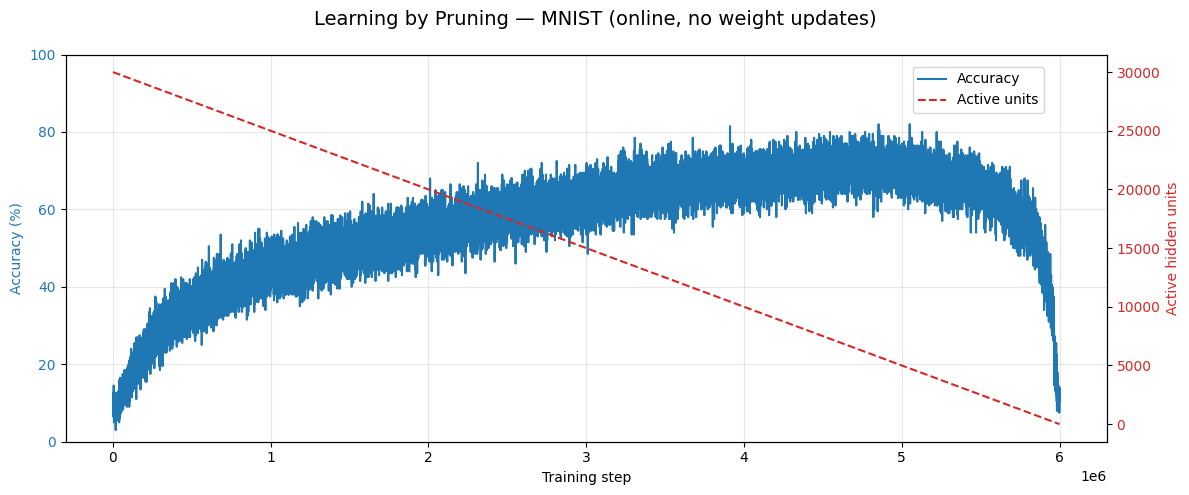

In [61]:
# ── Plot: accuracy over PRUNE_EVERY-step increments & active unit count ──
acc_per_interval = [chunk.mean() * 100 for chunk in all_corrects]
interval_centers = [(i + 0.5) * PRUNE_EVERY for i in range(len(acc_per_interval))]

fig, ax1 = plt.subplots(figsize=(12, 5))

color_acc = "tab:blue"
ax1.plot(interval_centers, acc_per_interval, color=color_acc, linewidth=1.5, label="Accuracy")
ax1.set_xlabel("Training step")
ax1.set_ylabel("Accuracy (%)", color=color_acc)
ax1.tick_params(axis="y", labelcolor=color_acc)
ax1.set_ylim(0, 100)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color_units = "tab:red"
ax2.plot(interval_centers, n_active_history, color=color_units, linewidth=1.5,
         linestyle="--", label="Active units")
ax2.set_ylabel("Active hidden units", color=color_units)
ax2.tick_params(axis="y", labelcolor=color_units)

fig.suptitle("Learning by Pruning — MNIST (online, no weight updates)", fontsize=14)
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
fig.tight_layout()
plt.show()